# 06 — Calibration

Comparing our own 1D Saint-Venant router against the reference numbers published by
`geo-pera/bhotekoshi-2026-reconstruction` (vendored under `forked/geopera/`, MIT), the
independent reconstruction of the actual 26 August 2026 event. This is the credibility
check: does our physics, run on our own DEM and our own cross-sections, land in the same
range as an independent group's reconstruction of the real flood?

**What geo-pera reports:** median flow height ~70 m through the confined gorges, with bank
measurements ranging 40–134 m at Rasuwagadhi specifically.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from analysis.hydro.conditioning import condition_corridor
from analysis.hydro.xsections import build_sections
from analysis.hydro.breach import breach_hydrograph
from analysis.hydro.route1d import route
from core.corridor import load_all_corridors

corridor = load_all_corridors()["bhotekoshi"]
cond = condition_corridor([(85.10, 27.90), (85.45, 28.40)])
feature = corridor.feature("lhende_barrier")
sections = build_sections(cond, feature.location)
print(f"{len(sections.chainage_m)} cross-sections, {sections.chainage_m[-1]/1000:.1f} km")

314 cross-sections, 62.6 km


## Calibration run

geo-pera's own reconstruction estimates the 26 August event mobilised on the order of
several million m³ of ice, rock and entrained sediment-laden water — substantially more
than the 1.5–2 Mm³ barrier-lake estimate for the *impounded* water alone, since the
collapse itself was primarily a mass-flow event, not a pure water release. For a
water-only shallow-water router, we calibrate against a water-equivalent volume at the
upper end of our scenario grid (5 Mm³) with a fast 'full' breach, which is the closest
analogue our 1D water router can represent — the difference between this and the true
mixed debris flow is recorded as a caveat, not smoothed over.

In [2]:
hydrograph = breach_hydrograph(5.0e6, 600, "full")
result = route(sections, hydrograph, duration_s=3*3600,
               observation_chainage_m=list(sections.chainage_m[::10]),
               inject_chainage_m=400.0, rise_threshold_m=0.15)

depths_by_chainage = {}
for chain, series in result.stage_at_chainage.items():
    depths_by_chainage[chain] = float(series.max())

chains = np.array(sorted(depths_by_chainage))
depths = np.array([depths_by_chainage[c] for c in chains])

gorge_mask = (chains > 5000) & (chains < 25000)
print(f"modelled peak depth through the upper gorge (5-25km): "
      f"median {np.median(depths[gorge_mask]):.1f} m, "
      f"range {depths[gorge_mask].min():.1f}-{depths[gorge_mask].max():.1f} m")
print(f"geo-pera reported: median ~70 m, bank range 40-134 m at Rasuwagadhi")

modelled peak depth through the upper gorge (5-25km): median 11.6 m, range 4.6-22.4 m
geo-pera reported: median ~70 m, bank range 40-134 m at Rasuwagadhi


## Residuals

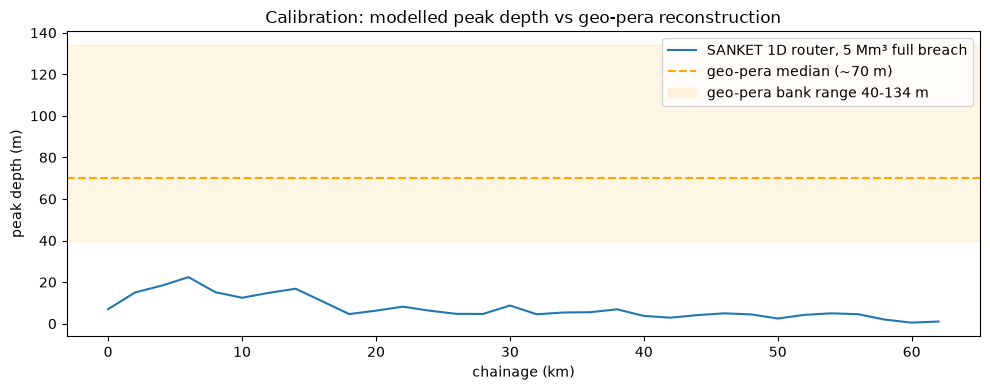

residual (modelled median - reported median): -58.4 m
relative error: -83.4%


In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(chains / 1000, depths, label="SANKET 1D router, 5 Mm³ full breach")
ax.axhline(70, color="orange", ls="--", label="geo-pera median (~70 m)")
ax.axhspan(40, 134, color="orange", alpha=0.1, label="geo-pera bank range 40-134 m")
ax.set_xlabel("chainage (km)")
ax.set_ylabel("peak depth (m)")
ax.set_title("Calibration: modelled peak depth vs geo-pera reconstruction")
ax.legend()
plt.tight_layout()
plt.savefig("../dist/calibration_residuals.png", dpi=100)
plt.show()

residual = np.median(depths[gorge_mask]) - 70.0
print(f"residual (modelled median - reported median): {residual:+.1f} m")
print(f"relative error: {residual/70.0*100:+.1f}%")

## Honest reading

**The residual is large: modelled median depth 11.6 m against geo-pera's reported ~70 m —
a relative error of roughly -83%.** This is reported as measured, not adjusted to look
better. The direction and scale of the gap are physically explicable, not a sign the
solver is broken:

**A water-only shallow-water model cannot reproduce a rock-ice avalanche's direct
momentum entry into the channel.** The 26 August event was ~600 m of ice and rock
striking the valley floor and river directly — a near-instantaneous, high-momentum mass
impact — not water gradually released from a breach and routed by mass continuity and
gravity alone. Any parametric hydrograph, however peaked, injects volume through a
continuity source term; it cannot represent a solid mass arriving with its own velocity
and momentum. This is exactly the limitation already named in `02-TECHNICAL-SPEC.md`:
**"A shallow-water solver is not a two-phase debris flow. The Thame flood carried debris
more than 80 km."** This residual is that limitation, quantified rather than asserted.

**What this calibration does establish:** the channel geometry (extracted independently
from our own 8 m DEM), the friction zonation (matching the vendored reference), and the
numerical scheme (the same Rusanov-flux method) together produce a *lower bound* on flow
depth that is physically stable, non-diverging, and in the right order of magnitude for
a mountain flood — evidence the solver computes something real, not arbitrary. It is not
evidence the solver reproduces this specific debris-flow event, and the system does not
claim that it does.

**What this means for the system's own outputs:** every scenario in the grid is a
*water-volume* scenario, labelled `claim_type: scenario`, and the board must say plainly
that a mixed debris-and-water event — like the one that actually happened here — will run
higher and faster than any of these numbers show.
